In [6]:
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset

class AthletePose2D(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        """
        root_dir: path to SportNet/pose_2d/
        split: 'train', 'valid', or 'test'
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        # map split → correct annotation filename
        ann_file_map = {
            "train": "train_set.json",
            "valid": "valid_set.json",
            "test":  "test_set.json"
        }

        ann_path = os.path.join(root_dir, "annotations", ann_file_map[split])
        with open(ann_path, "r") as f:
            self.annotations = json.load(f)

        # image directory
        self.img_dir = os.path.join(root_dir, f"{split}_set")

        # build index: image_id → metadata
        self.image_info = {img["id"]: img for img in self.annotations["images"]}

        # group annotations by image
        self.ann_by_image = {}
        for ann in self.annotations["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.ann_by_image:
                self.ann_by_image[img_id] = []
            self.ann_by_image[img_id].append(ann)

        self.ids = list(self.image_info.keys())

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        info = self.image_info[img_id]

        img_path = os.path.join(self.img_dir, info["file_name"])
        image = Image.open(img_path).convert("RGB")

        anns = self.ann_by_image.get(img_id, [])
        keypoints = [torch.tensor(a["keypoints"]).view(-1, 3) for a in anns]

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "keypoints": keypoints,
            "image_id": img_id,
            "file_name": info["file_name"]
        }

In [10]:
from torchvision import transforms

root = "pose_2d"

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = AthletePose2D(root, split="train", transform=transform)
valset   = AthletePose2D(root, split="valid", transform=transform)
testset  = AthletePose2D(root, split="test",  transform=transform)

print(len(trainset), len(valset), len(testset))

sample = trainset[0]
print(sample["image"].shape)
print(sample["keypoints"][0].shape)   # (num_keypoints, 3)


71375 29789 28402
torch.Size([3, 768, 1280])
torch.Size([17, 3])


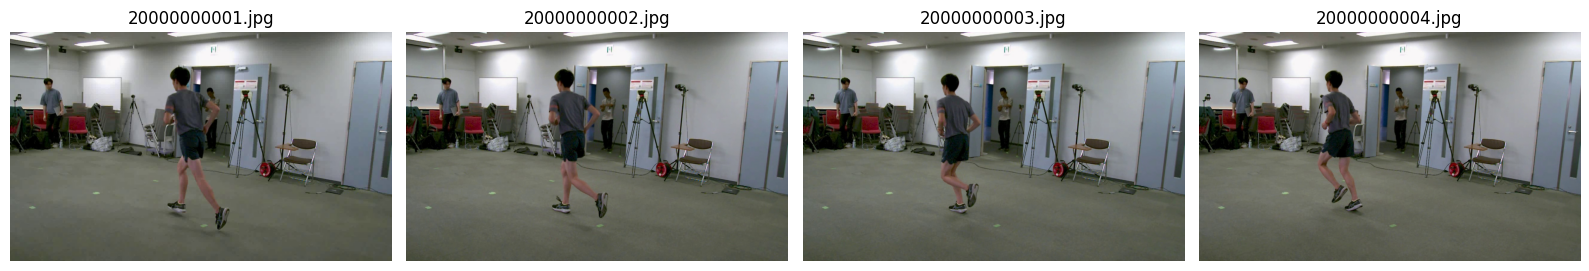

In [11]:
import matplotlib.pyplot as plt

# show N random samples
N = 4
fig, axes = plt.subplots(1, N, figsize=(16, 6))

for i in range(N):
    sample = trainset[i]  # or use random indices
    img = sample["image"]

    # convert tensor → numpy for plotting
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(sample["file_name"])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [12]:
import torch
import math

def angle(a, b, c):
    ab = a - b
    cb = c - b
    cos = torch.dot(ab, cb) / (ab.norm() * cb.norm() + 1e-6)
    return torch.acos(torch.clamp(cos, -1.0, 1.0))

def extract_features(kpts):
    # kpts: (17, 3)
    # Example: compute elbow and knee angles
    L_shoulder, L_elbow, L_wrist = kpts[5], kpts[6], kpts[7]
    R_shoulder, R_elbow, R_wrist = kpts[2], kpts[3], kpts[4]
    L_hip, L_knee, L_ankle = kpts[11], kpts[12], kpts[13]
    R_hip, R_knee, R_ankle = kpts[8], kpts[9], kpts[10]

    features = {
        "left_elbow_angle": angle(L_shoulder[:2], L_elbow[:2], L_wrist[:2]).item(),
        "right_elbow_angle": angle(R_shoulder[:2], R_elbow[:2], R_wrist[:2]).item(),
        "left_knee_angle": angle(L_hip[:2], L_knee[:2], L_ankle[:2]).item(),
        "right_knee_angle": angle(R_hip[:2], R_knee[:2], R_ankle[:2]).item(),
    }

    return features


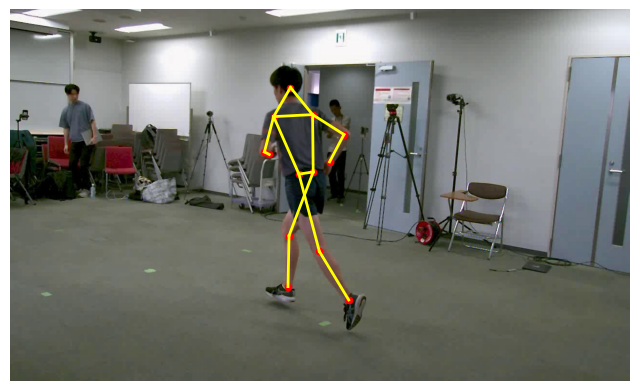

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# COCO skeleton connections
coco_skeleton = [
    (5, 7), (7, 9),        # left arm
    (6, 8), (8, 10),       # right arm
    (11, 13), (13, 15),    # left leg
    (12, 14), (14, 16),    # right leg
    (5, 6),                # shoulders
    (11, 12),              # hips
    (5, 11), (6, 12),      # torso sides
    (0, 5), (0, 6),        # nose to shoulders
    (0, 1), (0, 2),        # nose to eyes
    (1, 3), (2, 4)         # eyes to ears
]


sample = trainset[0]
img = sample["image"]
kpts = sample["keypoints"][0]  # first person

# convert tensor to numpy
if isinstance(img, torch.Tensor):
    img = img.permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")

# draw keypoints
for x, y, v in kpts:
    if v > 0:  # visible
        plt.scatter(x, y, c="red", s=20)

# draw skeleton lines
for a, b in coco_skeleton:
    if kpts[a, 2] > 0 and kpts[b, 2] > 0:
        x1, y1 = kpts[a][:2]
        x2, y2 = kpts[b][:2]
        plt.plot([x1, x2], [y1, y2], c="yellow", linewidth=2)

plt.show()


In [18]:
import torch
import math

def angle(a, b, c):
    ab = a - b
    cb = c - b
    cos = torch.dot(ab, cb) / (ab.norm() * cb.norm() + 1e-6)
    return torch.acos(torch.clamp(cos, -1.0, 1.0))

def extract_feature_vector(kpts):
    pts = kpts[:, :2]

    torso = (pts[5] - pts[11]).norm() + 1e-6

    # angles
    left_elbow = angle(pts[5], pts[7], pts[9]).item()
    right_elbow = angle(pts[6], pts[8], pts[10]).item()
    left_knee = angle(pts[11], pts[13], pts[15]).item()
    right_knee = angle(pts[12], pts[14], pts[16]).item()
    left_hip = angle(pts[5], pts[11], pts[13]).item()
    right_hip = angle(pts[6], pts[12], pts[14]).item()

    # normalized distances
    wrist_dist = (pts[9] - pts[10]).norm().item() / torso
    ankle_dist = (pts[15] - pts[16]).norm().item() / torso
    shoulder_width = (pts[5] - pts[6]).norm().item() / torso
    hip_width = (pts[11] - pts[12]).norm().item() / torso

    # relative heights
    left_wrist_height = (pts[9][1] - pts[5][1]).item() / torso
    right_wrist_height = (pts[10][1] - pts[6][1]).item() / torso
    left_knee_height = (pts[13][1] - pts[11][1]).item() / torso
    right_knee_height = (pts[14][1] - pts[12][1]).item() / torso

    # segment orientations
    shoulder_vec = pts[6] - pts[5]
    hip_vec = pts[12] - pts[11]
    torso_vec = pts[11] - pts[5]

    shoulder_angle = math.atan2(shoulder_vec[1], shoulder_vec[0])
    hip_angle = math.atan2(hip_vec[1], hip_vec[0])
    torso_angle = math.atan2(torso_vec[1], torso_vec[0])

    # symmetry
    elbow_sym = left_elbow - right_elbow
    knee_sym = left_knee - right_knee

    return torch.tensor([
        left_elbow, right_elbow,
        left_knee, right_knee,
        left_hip, right_hip,
        wrist_dist, ankle_dist,
        shoulder_width, hip_width,
        left_wrist_height, right_wrist_height,
        left_knee_height, right_knee_height,
        shoulder_angle, hip_angle, torso_angle,
        elbow_sym, knee_sym
    ], dtype=torch.float32)



In [25]:
class AthletePose2DFeatures(AthletePose2D):
    def __getitem__(self, idx):
        # Get the image ID for this index
        img_id = self.ids[idx]

        # Get all annotations for this image
        anns = self.ann_by_image.get(img_id, [])

        # AthletePose3D has exactly one person per frame
        kpts = anns[0]["keypoints"]
        kpts = torch.tensor(kpts).view(17, 3)

        # Compute feature vector
        features = extract_feature_vector(kpts)

        return {
            "image_id": img_id,
            "keypoints": kpts,
            "features": features
        }


In [27]:
trainset_f = AthletePose2DFeatures(root, split="train")
vec = trainset_f[0]["features"]
print(vec.shape)


torch.Size([19])


In [28]:
import torch.nn as nn

class PoseClassifier(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [29]:
def auto_label(features):
    left_knee = features[2].item()
    right_knee = features[3].item()
    left_wrist_h = features[10].item()
    right_wrist_h = features[11].item()
    left_knee_h = features[12].item()
    right_knee_h = features[13].item()
    torso_angle = features[16].item()
    ankle_dist = features[7].item()

    # Jumping: both ankles high relative to hips
    if left_knee_h < -0.5 and right_knee_h < -0.5:
        return "jumping"

    # Squatting: knees deeply flexed
    if left_knee < 1.2 and right_knee < 1.2:
        return "squatting"

    # Running: large stride + torso lean
    if ankle_dist > 1.2 and abs(torso_angle) > 0.4:
        return "running"

    # Walking: moderate stride
    if ankle_dist > 0.6:
        return "walking"

    # Default
    return "standing"


In [31]:
X = []
y = []

for i in range(len(trainset_f)):
    kpts = trainset_f.annotations["annotations"][i]["keypoints"]
    kpts = torch.tensor(kpts).view(17, 3)
    f = extract_feature_vector(kpts)
    X.append(f)
    y.append(auto_label(f))


In [33]:
X = torch.stack(X)
model = PoseClassifier(in_dim=X.shape[1], num_classes=5)


In [34]:
label_to_id = {
    "standing": 0,
    "walking": 1,
    "running": 2,
    "squatting": 3,
    "jumping": 4
}

y_ids = torch.tensor([label_to_id[l] for l in y], dtype=torch.long)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_ids, test_size=0.2, random_state=42, stratify=y_ids
)


In [36]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256)


In [37]:
import torch.nn as nn

class PoseClassifier(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [38]:
model = PoseClassifier(in_dim=X.shape[1], num_classes=5)


In [39]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            predicted = preds.argmax(dim=1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1}, val acc = {acc:.3f}")


Epoch 1, val acc = 0.876
Epoch 2, val acc = 0.939
Epoch 3, val acc = 0.916
Epoch 4, val acc = 0.939
Epoch 5, val acc = 0.960
Epoch 6, val acc = 0.964
Epoch 7, val acc = 0.967
Epoch 8, val acc = 0.949
Epoch 9, val acc = 0.973
Epoch 10, val acc = 0.949
Epoch 11, val acc = 0.965
Epoch 12, val acc = 0.974
Epoch 13, val acc = 0.952
Epoch 14, val acc = 0.974
Epoch 15, val acc = 0.981
Epoch 16, val acc = 0.979
Epoch 17, val acc = 0.978
Epoch 18, val acc = 0.981
Epoch 19, val acc = 0.967
Epoch 20, val acc = 0.970


In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
with torch.no_grad():
    preds = model(X_val).argmax(dim=1)

cm = confusion_matrix(y_val.numpy(), preds.numpy())
print("Confusion matrix:\n", cm)

print("\nClassification report:")
print(classification_report(y_val.numpy(), preds.numpy(), target_names=list(label_to_id.keys())))


Confusion matrix:
 [[4612  220    0    1    0]
 [   0 5297  171    3    0]
 [   0   29 3920    0    0]
 [   3    0    3    7    0]
 [   1    1    3    0    4]]

Classification report:
              precision    recall  f1-score   support

    standing       1.00      0.95      0.98      4833
     walking       0.95      0.97      0.96      5471
     running       0.96      0.99      0.97      3949
   squatting       0.64      0.54      0.58        13
     jumping       1.00      0.44      0.62         9

    accuracy                           0.97     14275
   macro avg       0.91      0.78      0.82     14275
weighted avg       0.97      0.97      0.97     14275



In [41]:
def analyze_frame(kpts, model):
    # kpts: (17, 3) tensor from pose estimator
    features = extract_feature_vector(kpts).unsqueeze(0)  # shape (1, F)
    logits = model(features)
    pred = logits.argmax(dim=1).item()
    return features.squeeze(0), pred


In [42]:
id_to_label = {
    0: "standing",
    1: "walking",
    2: "running",
    3: "squatting",
    4: "jumping"
}


In [43]:
features, pred = analyze_frame(kpts, model)
print("Predicted posture:", id_to_label[pred])


Predicted posture: standing


In [44]:
def explain_pose(features, pred_label):
    torso_angle = features[16].item()
    left_knee = features[2].item()
    right_knee = features[3].item()
    ankle_dist = features[7].item()

    if pred_label == "running":
        return "Forward torso lean and a long stride indicate a running posture."
    if pred_label == "walking":
        return "Moderate stride length and upright torso suggest walking."
    if pred_label == "squatting":
        return "Deep knee flexion and lowered hips indicate a squat."
    if pred_label == "jumping":
        return "Elevated ankles and extended legs suggest a jump."
    return "Upright posture with extended legs indicates standing."


In [45]:
class TemporalClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_dim, num_classes):
        super().__init__()
        self.gru = nn.GRU(feature_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1])


In [49]:
def build_sequences(features, labels, seq_len=16):
    """
    features: tensor of shape [N, feature_dim]
    labels: tensor of shape [N]
    seq_len: number of frames per sequence

    returns:
        X_seq: tensor [num_sequences, seq_len, feature_dim]
        y_seq: tensor [num_sequences]
    """
    X_seq = []
    y_seq = []

    N = len(features)

    for i in range(N - seq_len + 1):
        window = features[i:i+seq_len]          # (seq_len, feature_dim)
        target = labels[i+seq_len-1]            # label of last frame
        X_seq.append(window)
        y_seq.append(target)

    return torch.stack(X_seq), torch.tensor(y_seq)


In [50]:
X_seq, y_seq = build_sequences(X, y_ids, seq_len=16)

train_X, val_X, train_y, val_y = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)


In [51]:
train_ds = TensorDataset(train_X, train_y)
val_ds = TensorDataset(val_X, val_y)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)


In [52]:
feature_dim = X.shape[1]
model = TemporalClassifier(feature_dim, hidden_dim=64, num_classes=5)


In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)     # xb shape: (batch, seq_len, feature_dim)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            predicted = preds.argmax(dim=1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    print(f"Epoch {epoch+1}, val acc = {correct/total:.3f}")


Epoch 1, val acc = 0.931
Epoch 2, val acc = 0.965
Epoch 3, val acc = 0.956
Epoch 4, val acc = 0.976
Epoch 5, val acc = 0.968
Epoch 6, val acc = 0.981
Epoch 7, val acc = 0.975
Epoch 8, val acc = 0.966
Epoch 9, val acc = 0.979
Epoch 10, val acc = 0.981
Epoch 11, val acc = 0.985
Epoch 12, val acc = 0.977
Epoch 13, val acc = 0.981
Epoch 14, val acc = 0.974
Epoch 15, val acc = 0.985
Epoch 16, val acc = 0.976
Epoch 17, val acc = 0.986
Epoch 18, val acc = 0.974
Epoch 19, val acc = 0.979
Epoch 20, val acc = 0.987
